## Quick missingness check

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_excel('data/pwt110_download_2025_11_24.xlsx', sheet_name='Data')

# Get Bolivia data 
bolivia = df[df['country'] == 'Bolivia (Plurinational State of)'].copy()
bolivia = bolivia.sort_values('year')

# Check the data we need
print(f"Years available: {bolivia['year'].min()} to {bolivia['year'].max()}")
print(f"Total observations: {len(bolivia)}")

# Check for missing values in key variables
key_vars = ['rgdpna', 'pop', 'emp', 'rnna', 'hc']
print("\nMissing values check:")
for var in key_vars:
    missing = bolivia[var].isna().sum()
    print(f"{var}: {missing} missing")

Years available: 1950 to 2023
Total observations: 74

Missing values check:
rgdpna: 0 missing
pop: 0 missing
emp: 0 missing
rnna: 0 missing
hc: 0 missing


## Section A Trend Calculation
---

### A1 Transform variables using logs

In [2]:
# First calculate GDP per capita
bolivia['gdp_per_capita'] = bolivia['rgdpna'] / bolivia['pop']

# Take natural logs
bolivia['ln_gdp'] = np.log(bolivia['rgdpna'])
bolivia['ln_gdp_pc'] = np.log(bolivia['gdp_per_capita'])

### A2 Fit trends using provided function

In [3]:
from get_regression_coefs_general import get_regression_coefs

# Create time variable for regression
bolivia['time'] = range(len(bolivia))

# Fit trend for log GDP
ones = np.ones(len(bolivia))
time = bolivia['time'].values
ln_gdp = bolivia['ln_gdp'].values

coefs_ln_gdp = get_regression_coefs(ln_gdp, ones, time)
print(f"Log GDP trend: intercept = {coefs_ln_gdp[0]:.4f}, slope = {coefs_ln_gdp[1]:.4f}")

# Fit trend for log GDP per capita
ln_gdp_pc = bolivia['ln_gdp_pc'].values
coefs_ln_gdp_pc = get_regression_coefs(ln_gdp_pc, ones, time)
print(f"Log GDP per capita trend: intercept = {coefs_ln_gdp_pc[0]:.4f}, slope = {coefs_ln_gdp_pc[1]:.4f}")

# Calculate fitted values
bolivia['ln_gdp_trend'] = coefs_ln_gdp[0] + coefs_ln_gdp[1] * bolivia['time']
bolivia['ln_gdp_pc_trend'] = coefs_ln_gdp_pc[0] + coefs_ln_gdp_pc[1] * bolivia['time']

Log GDP trend: intercept = 9.6109, slope = 0.0267
Log GDP per capita trend: intercept = 8.4972, slope = 0.0065


### A3 Plot trends for GDP and GDP per capita

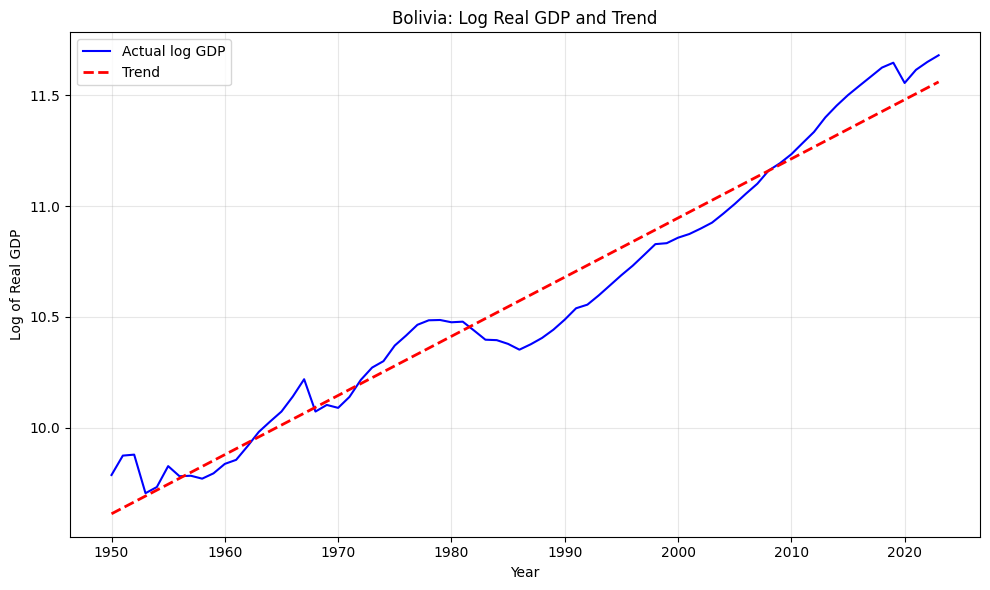

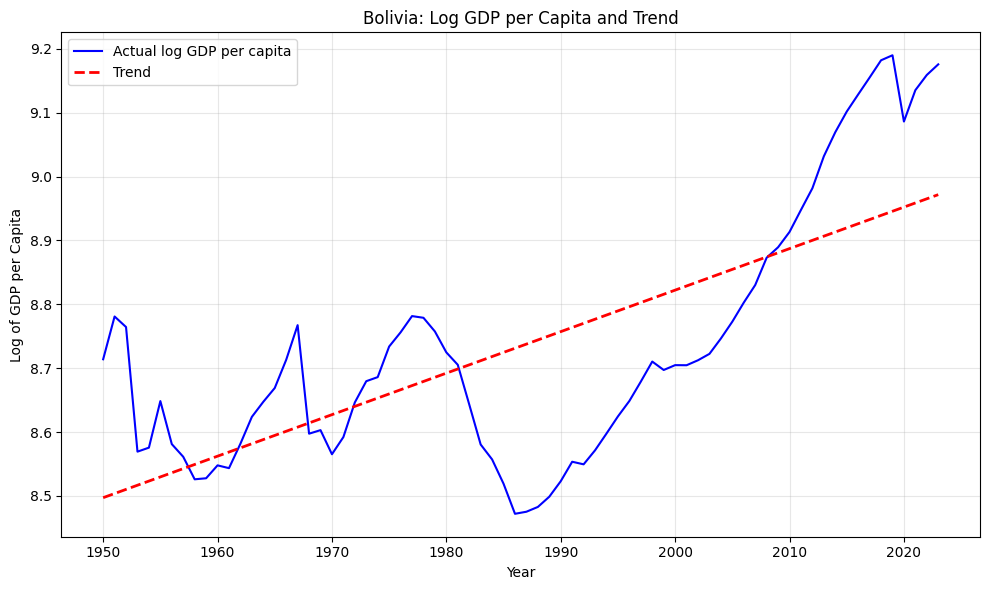

Figures saved to data/figures/


In [4]:
# Cell 4: Plot log GDP and log GDP per capita with trends

# Figure 1: Log GDP
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(bolivia['year'], bolivia['ln_gdp'], label='Actual log GDP', color='blue', linewidth=1.5)
ax1.plot(bolivia['year'], bolivia['ln_gdp_trend'], label='Trend', color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Year')
ax1.set_ylabel('Log of Real GDP')
ax1.set_title('Bolivia: Log Real GDP and Trend')
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/figures/fig1_log_gdp_trend.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Log GDP per capita
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(bolivia['year'], bolivia['ln_gdp_pc'], label='Actual log GDP per capita', color='blue', linewidth=1.5)
ax2.plot(bolivia['year'], bolivia['ln_gdp_pc_trend'], label='Trend', color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Year')
ax2.set_ylabel('Log of GDP per Capita')
ax2.set_title('Bolivia: Log GDP per Capita and Trend')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/figures/fig2_log_gdp_pc_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figures saved to data/figures/")

### A4 Transform variables using logs

In [5]:
# Fit trend for GDP level
gdp_level = bolivia['rgdpna'].values
coefs_gdp = get_regression_coefs(gdp_level, ones, time)
print(f"GDP level trend: intercept = {coefs_gdp[0]:.2f}, slope = {coefs_gdp[1]:.2f}")

# Fit trend for GDP per capita level
gdp_pc_level = bolivia['gdp_per_capita'].values
coefs_gdp_pc = get_regression_coefs(gdp_pc_level, ones, time)
print(f"GDP per capita level trend: intercept = {coefs_gdp_pc[0]:.2f}, slope = {coefs_gdp_pc[1]:.2f}")

# Calculate fitted values for levels
bolivia['gdp_trend'] = coefs_gdp[0] + coefs_gdp[1] * bolivia['time']
bolivia['gdp_pc_trend'] = coefs_gdp_pc[0] + coefs_gdp_pc[1] * bolivia['time']

GDP level trend: intercept = 1032.08, slope = 1264.01
GDP per capita level trend: intercept = 4669.84, slope = 45.89


### A5 Plot levels with trends (robustness check) and save figures


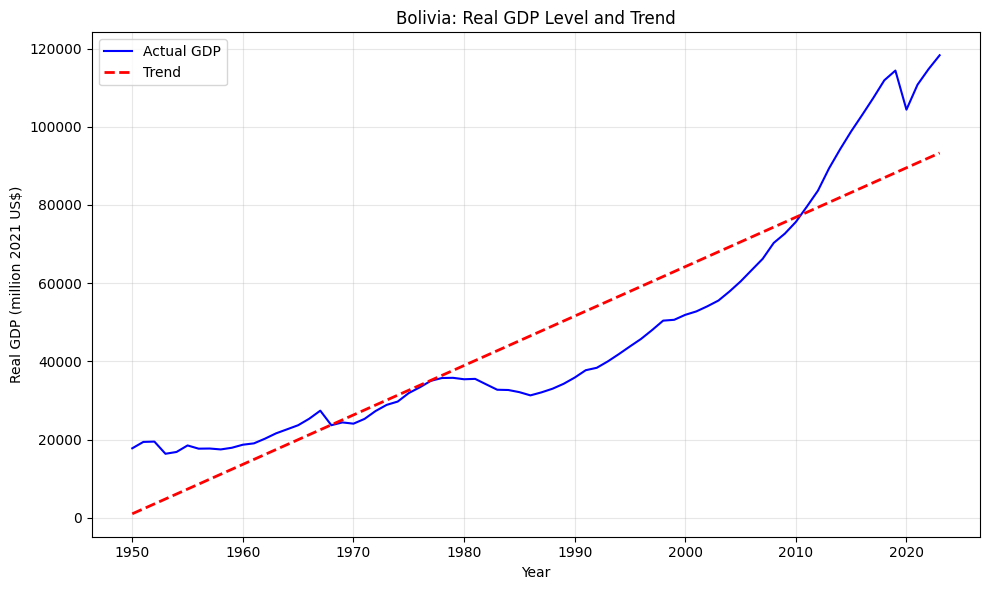

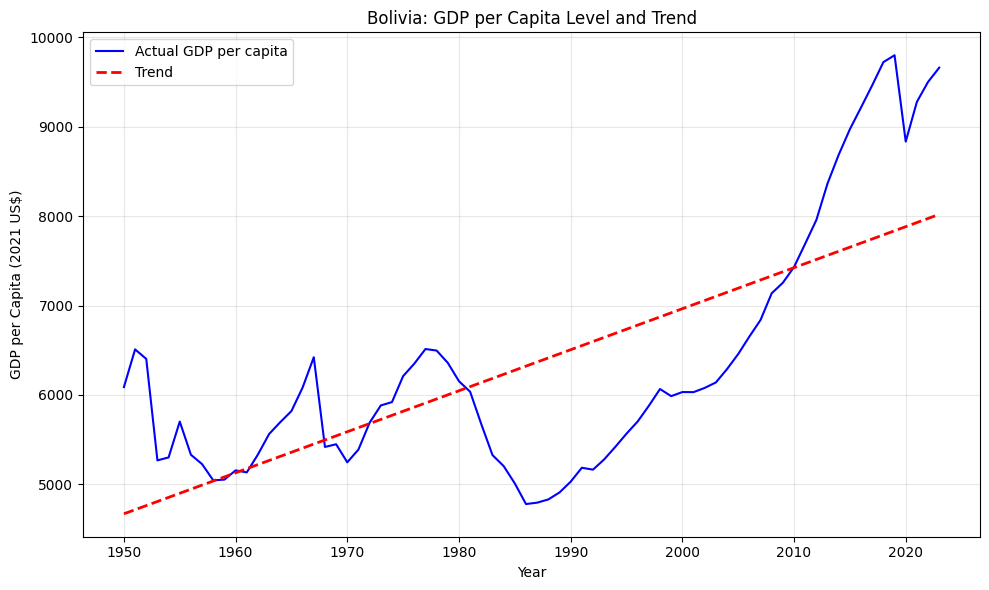

Figures saved to data/figures/


In [6]:

# Figure 1: GDP level
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(bolivia['year'], bolivia['rgdpna'], label='Actual GDP', color='blue', linewidth=1.5)
ax1.plot(bolivia['year'], bolivia['gdp_trend'], label='Trend', color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Year')
ax1.set_ylabel('Real GDP (million 2021 US$)')
ax1.set_title('Bolivia: Real GDP Level and Trend')
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/figures/fig3_gdp_level_trend.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: GDP per capita level
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(bolivia['year'], bolivia['gdp_per_capita'], label='Actual GDP per capita', color='blue', linewidth=1.5)
ax2.plot(bolivia['year'], bolivia['gdp_pc_trend'], label='Trend', color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Year')
ax2.set_ylabel('GDP per Capita (2021 US$)')
ax2.set_title('Bolivia: GDP per Capita Level and Trend')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/figures/fig4_gdp_pc_level_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figures saved to data/figures/")

---
### A6 encode + plot for trend lines

In [ ]:
# Fit all 4 trend specifications for both GDP and GDP per capita
bolivia['time2'] = bolivia['time'] ** 2

# Additive + Linear 
coefs_add_lin = np.polyfit(bolivia['time'], bolivia['rgdpna'], 1)
bolivia['gdp_add_lin'] = np.polyval(coefs_add_lin, bolivia['time'])

coefs_pc_add_lin = np.polyfit(bolivia['time'], bolivia['gdp_per_capita'], 1)
bolivia['gdp_pc_add_lin'] = np.polyval(coefs_pc_add_lin, bolivia['time'])

# Additive + Quadratic 
coefs_add_quad = np.polyfit(bolivia['time'], bolivia['rgdpna'], 2)
bolivia['gdp_add_quad'] = np.polyval(coefs_add_quad, bolivia['time'])

coefs_pc_add_quad = np.polyfit(bolivia['time'], bolivia['gdp_per_capita'], 2)
bolivia['gdp_pc_add_quad'] = np.polyval(coefs_pc_add_quad, bolivia['time'])

# Exponential + Linear (already have this, but redo for consistency) 
coefs_exp_lin = np.polyfit(bolivia['time'], bolivia['ln_gdp'], 1)
bolivia['ln_gdp_exp_lin'] = np.polyval(coefs_exp_lin, bolivia['time'])

coefs_pc_exp_lin = np.polyfit(bolivia['time'], bolivia['ln_gdp_pc'], 1)
bolivia['ln_gdp_pc_exp_lin'] = np.polyval(coefs_pc_exp_lin, bolivia['time'])

# Exponential + Quadratic 
coefs_exp_quad = np.polyfit(bolivia['time'], bolivia['ln_gdp'], 2)
bolivia['ln_gdp_exp_quad'] = np.polyval(coefs_exp_quad, bolivia['time'])

coefs_pc_exp_quad = np.polyfit(bolivia['time'], bolivia['ln_gdp_pc'], 2)
bolivia['ln_gdp_pc_exp_quad'] = np.polyval(coefs_pc_exp_quad, bolivia['time'])

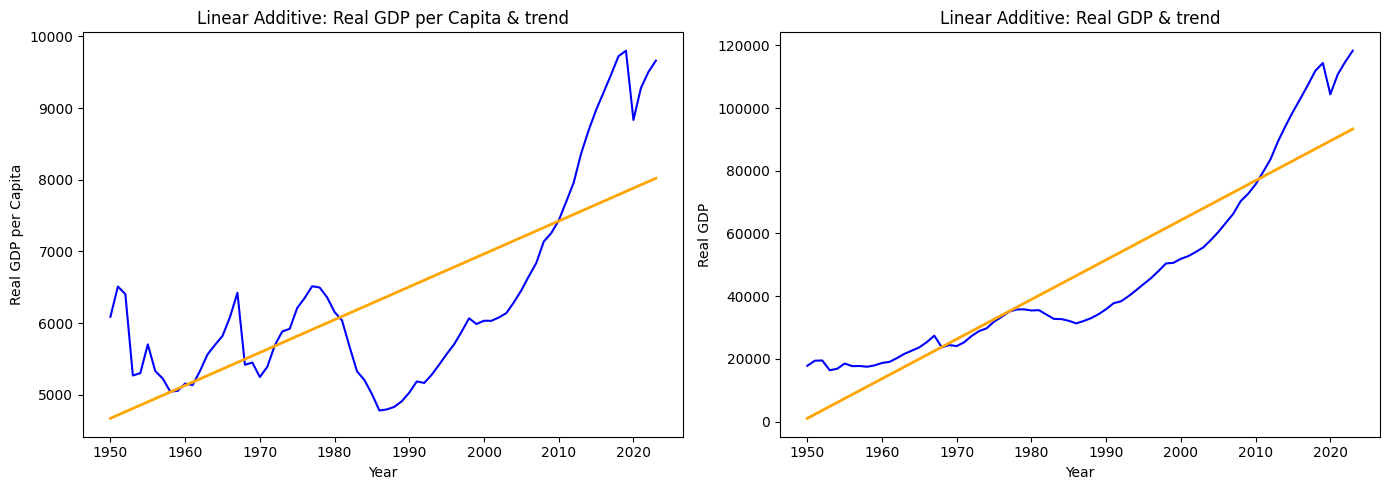

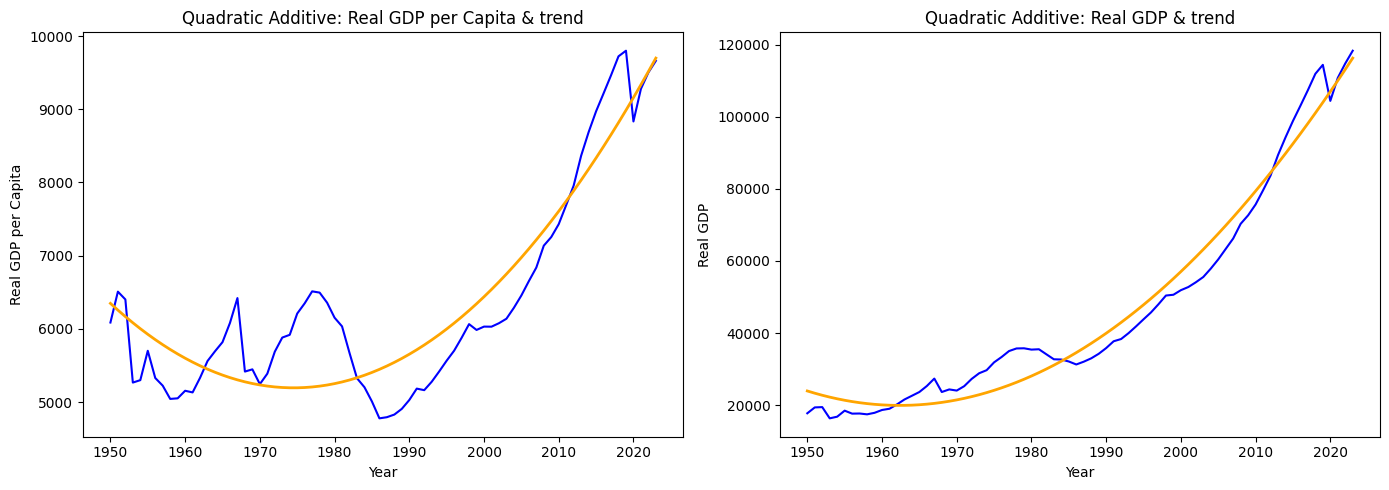

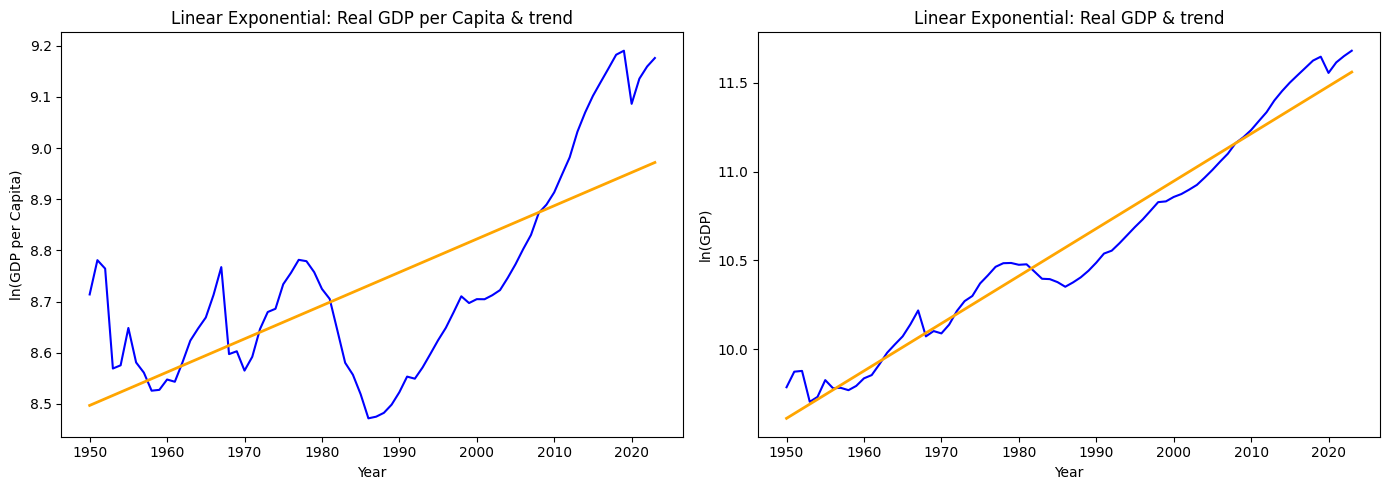

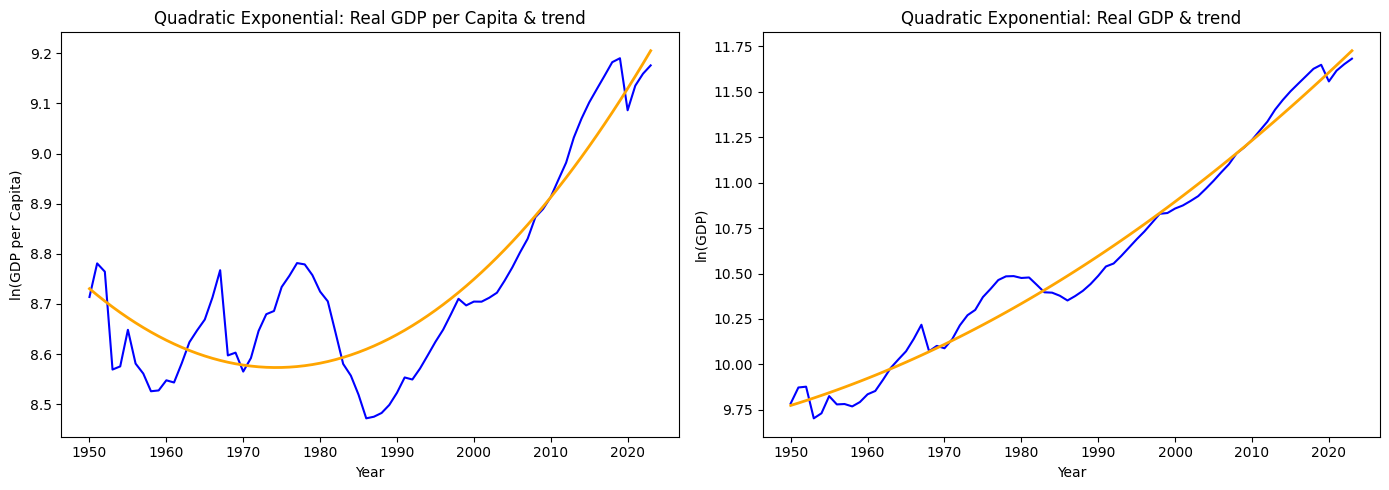

In [8]:
specs = [
    ('Additive', 'Linear', 'gdp_per_capita', 'gdp_pc_add_lin', 'rgdpna', 'gdp_add_lin'),
    ('Additive', 'Quadratic', 'gdp_per_capita', 'gdp_pc_add_quad', 'rgdpna', 'gdp_add_quad'),
    ('Exponential', 'Linear', 'ln_gdp_pc', 'ln_gdp_pc_exp_lin', 'ln_gdp', 'ln_gdp_exp_lin'),
    ('Exponential', 'Quadratic', 'ln_gdp_pc', 'ln_gdp_pc_exp_quad', 'ln_gdp', 'ln_gdp_exp_quad'),
]

ylabels = {
    'gdp_per_capita': 'Real GDP per Capita',
    'rgdpna': 'Real GDP',
    'ln_gdp_pc': 'ln(GDP per Capita)',
    'ln_gdp': 'ln(GDP)',
}

for add_exp, lin_quad, pc_col, pc_trend, gdp_col, gdp_trend in specs:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # GDP per capita
    ax1.plot(bolivia['year'], bolivia[pc_col], linewidth=1.5, color='blue')
    ax1.plot(bolivia['year'], bolivia[pc_trend], linewidth=2, color='orange')
    ax1.set_xlabel('Year')
    ax1.set_ylabel(ylabels[pc_col])
    ax1.set_title(f'{lin_quad} {add_exp}: Real GDP per Capita & trend')
    
    # GDP
    ax2.plot(bolivia['year'], bolivia[gdp_col], linewidth=1.5, color='blue')
    ax2.plot(bolivia['year'], bolivia[gdp_trend], linewidth=2, color='orange')
    ax2.set_xlabel('Year')
    ax2.set_ylabel(ylabels[gdp_col])
    ax2.set_title(f'{lin_quad} {add_exp}: Real GDP & trend')
    
    plt.tight_layout()
    plt.savefig(f'data/figures/fig_{add_exp.lower()}_{lin_quad.lower()}_trend.png', dpi=300, bbox_inches='tight')
    plt.show()

## Section B TFP
---

## Part B: Extract TFP Measure

We use the **Solow production function with human capital**:

$$Y = A \times K^\alpha \times (hL)^{1-\alpha}$$

Where:
- Y = Real GDP (rgdpna)
- K = Capital stock (rnna)
- L = Employment (emp)
- h = Human capital index (hc)
- A = Total Factor Productivity (TFP)
- α = Capital share (benchmark: 0.3)

We set **α = 0.3** as specified in the project instructions. This represents capital's share of income in the production function.

Rearranging to solve for TFP:

$$A = \frac{Y}{K^\alpha \times (hL)^{1-\alpha}}$$

We test robustness with α = 0.25, 0.30, and 0.35 as required.

In [9]:


alpha = 0.3

Y = bolivia['rgdpna'].values
K = bolivia['rnna'].values
L = bolivia['emp'].values
h = bolivia['hc'].values

# Calculate TFP (neutral specification with human capital)
bolivia['tfp'] = Y / ((K ** alpha) * ((h * L) ** (1 - alpha)))
bolivia['ln_tfp'] = np.log(bolivia['tfp'])

print("TFP calculated successfully!")
print(bolivia['tfp'].describe())

TFP calculated successfully!
count     74.000000
mean     358.813521
std       42.759104
min      302.591573
25%      314.911832
50%      358.369681
75%      391.329544
max      446.473235
Name: tfp, dtype: float64


### B2 Robustness check α


In [11]:
# Cell 8: Robustness check - try different alpha values
alphas_to_test = [0.25, 0.3, 0.35]

print("TFP calculations with different alpha values:\n")
for a in alphas_to_test:
    tfp_temp = Y / ((K ** a) * ((h * L) ** (1 - a)))
    print(f"Alpha = {a}:")
    print(f"  Mean TFP: {tfp_temp.mean():.2f}")
    print(f"  Std TFP: {tfp_temp.std():.2f}")
    print(f"  Min TFP: {tfp_temp.min():.2f}")
    print(f"  Max TFP: {tfp_temp.max():.2f}\n")

# Store TFP with different alphas for comparison
bolivia['tfp_025'] = Y / ((K ** 0.25) * ((h * L) ** 0.75))
bolivia['tfp_035'] = Y / ((K ** 0.35) * ((h * L) ** 0.65))

# Check robustness - do growth rates change with different alphas?
print("\nTFP growth rates over full period (1950-2023):\n")
for a in alphas_to_test:
    tfp_temp = Y / ((K ** a) * ((h * L) ** (1 - a)))
    ln_tfp_temp = np.log(tfp_temp)
    tfp_growth = (ln_tfp_temp[-1] - ln_tfp_temp[0]) / (bolivia['year'].iloc[-1] - bolivia['year'].iloc[0]) * 100
    print(f"Alpha = {a}: Annual TFP growth = {tfp_growth:.3f}%")

TFP calculations with different alpha values:

Alpha = 0.25:
  Mean TFP: 585.25
  Std TFP: 71.54
  Min TFP: 490.46
  Max TFP: 734.30

Alpha = 0.3:
  Mean TFP: 358.81
  Std TFP: 42.47
  Min TFP: 302.59
  Max TFP: 446.47

Alpha = 0.35:
  Mean TFP: 220.00
  Std TFP: 25.36
  Min TFP: 186.69
  Max TFP: 274.43


TFP growth rates over full period (1950-2023):

Alpha = 0.25: Annual TFP growth = -0.342%
Alpha = 0.3: Annual TFP growth = -0.377%
Alpha = 0.35: Annual TFP growth = -0.411%


the avg annual growth rates all seem quite similar, i.e. α is robust

---
## Section C: growth accounting

### C1 Calc contributions

We growth account by taking long periods of time and averaging, not by averaging Yoy growth rate

In [12]:
# Calculate log values for growth accounting
bolivia['ln_Y'] = np.log(bolivia['rgdpna'])
bolivia['ln_K'] = np.log(bolivia['rnna'])
bolivia['ln_L'] = np.log(bolivia['emp'])
bolivia['ln_h'] = np.log(bolivia['hc'])
# ln_tfp already exists 

def growth_accounting(df, start_idx, end_idx, alpha=0.3):
    """Calculate growth contributions over a period"""
    years_elapsed = df['year'].iloc[end_idx] - df['year'].iloc[start_idx]
    
    # Calculate log differences
    g_Y = (df['ln_Y'].iloc[end_idx] - df['ln_Y'].iloc[start_idx]) / years_elapsed
    g_K = (df['ln_K'].iloc[end_idx] - df['ln_K'].iloc[start_idx]) / years_elapsed
    g_L = (df['ln_L'].iloc[end_idx] - df['ln_L'].iloc[start_idx]) / years_elapsed
    g_h = (df['ln_h'].iloc[end_idx] - df['ln_h'].iloc[start_idx]) / years_elapsed
    g_A = (df['ln_tfp'].iloc[end_idx] - df['ln_tfp'].iloc[start_idx]) / years_elapsed
    
    # Calculate contribution as fraction of total growth
    contrib_K = alpha * g_K / g_Y
    contrib_L = (1 - alpha) * g_L / g_Y
    contrib_h = (1 - alpha) * g_h / g_Y
    contrib_A = g_A / g_Y
    
    return {
        'years': f"{int(df['year'].iloc[start_idx])}-{int(df['year'].iloc[end_idx])}",
        'g_Y': g_Y,
        'contrib_K': contrib_K,
        'contrib_L': contrib_L,
        'contrib_h': contrib_h,
        'contrib_A': contrib_A
    }

# Full period
full_period = growth_accounting(bolivia, 0, len(bolivia)-1)
print("Full period growth accounting:")
print(f"Period: {full_period['years']}")
print(f"Annual GDP growth: {full_period['g_Y']*100:.2f}%")
print(f"Capital contribution: {full_period['contrib_K']:.3f}")
print(f"Labor contribution: {full_period['contrib_L']:.3f}")
print(f"Human capital contribution: {full_period['contrib_h']:.3f}")
print(f"TFP contribution: {full_period['contrib_A']:.3f}")
print(f"Sum: {full_period['contrib_K'] + full_period['contrib_L'] + full_period['contrib_h'] + full_period['contrib_A']:.3f}")

Full period growth accounting:
Period: 1950-2023
Annual GDP growth: 2.60%
Capital contribution: 0.399
Labor contribution: 0.433
Human capital contribution: 0.313
TFP contribution: -0.145
Sum: 1.000


### C2 growth accounting for differrent subperiods

We use 4 long term sub periods to get  growth accounting insights

In [13]:
# Find position for different periods
def find_year_position(year):
    return bolivia[bolivia['year'] == year].index.tolist()[0] - bolivia.index[0]

# Define sub-periods
periods = [
    (1950, 1985),
    (1985, 2005),
    (2005, 2020)
]

results = []
for start_yr, end_yr in periods:
    start_pos = find_year_position(start_yr)
    end_pos = find_year_position(end_yr)
    result = growth_accounting(bolivia, start_pos, end_pos)
    results.append(result)

# Print results in a table format
print("\nGrowth Accounting by Sub-Period:\n")
print(f"{'Period':<12} {'GDP Growth':<12} {'Capital':<10} {'Labor':<10} {'Human K':<10} {'TFP':<10}")
print("-" * 70)
for r in results:
    print(f"{r['years']:<12} {r['g_Y']*100:>6.2f}%      {r['contrib_K']:>6.3f}     {r['contrib_L']:>6.3f}     {r['contrib_h']:>6.3f}     {r['contrib_A']:>6.3f}")


Growth Accounting by Sub-Period:

Period       GDP Growth   Capital    Labor      Human K    TFP       
----------------------------------------------------------------------
1950-1985      1.69%       0.631      0.244      0.491     -0.366
1985-2005      3.16%       0.231      0.524      0.294     -0.050
2005-2020      3.64%       0.389      0.490      0.174     -0.053


### C3 TFP plot

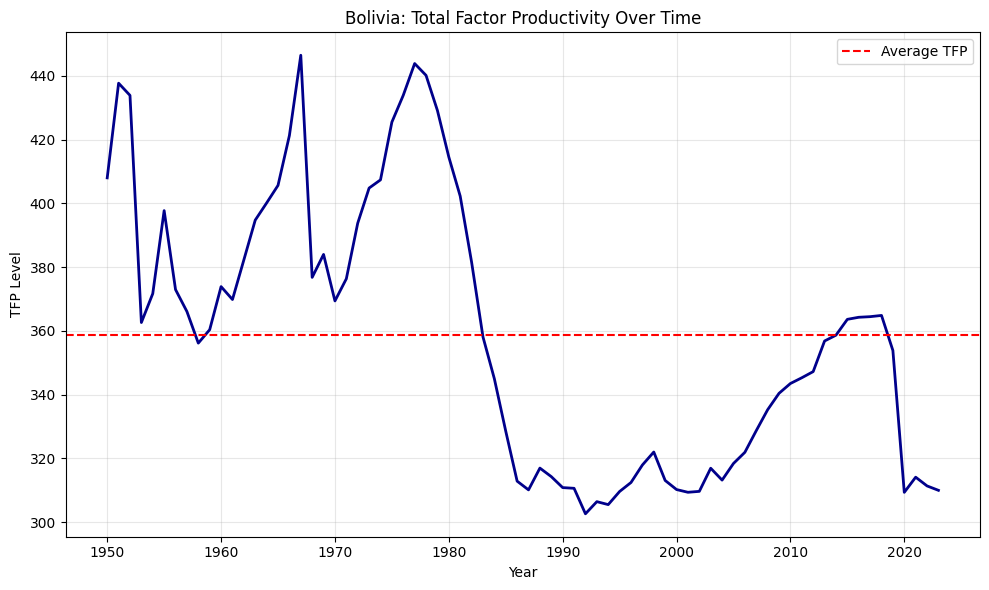


TFP levels at start/end of each period:
1950-1985: TFP changed from 408.00 to 328.52 (-19.5%)
1985-2005: TFP changed from 328.52 to 318.38 (-3.1%)
2005-2020: TFP changed from 318.38 to 309.32 (-2.8%)

Figure saved to data/figures/


In [14]:
#Plot TFP over time to see the pattern visually
fig5, ax5 = plt.subplots(figsize=(10, 6))
ax5.plot(bolivia['year'], bolivia['tfp'], linewidth=2, color='darkblue')
ax5.set_xlabel('Year')
ax5.set_ylabel('TFP Level')
ax5.set_title('Bolivia: Total Factor Productivity Over Time')
ax5.grid(True, alpha=0.3)
ax5.axhline(y=bolivia['tfp'].mean(), color='red', linestyle='--', label='Average TFP')
ax5.legend()
plt.tight_layout()
plt.savefig('data/figures/fig5_tfp_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

# Show key statistics for each period
print("\nTFP levels at start/end of each period:")
for start_yr, end_yr in periods:
    start_pos = find_year_position(start_yr)
    end_pos = find_year_position(end_yr)
    tfp_start = bolivia['tfp'].iloc[start_pos]
    tfp_end = bolivia['tfp'].iloc[end_pos]
    print(f"{start_yr}-{end_yr}: TFP changed from {tfp_start:.2f} to {tfp_end:.2f} ({((tfp_end/tfp_start)-1)*100:+.1f}%)")

print("\nFigure saved to data/figures/")

---
## D. Labour Productivtity

### D1 Plot Labour Productivity over time

Labour Productivity Summary:
count       74.000000
mean     14009.765762
std       3064.810656
min       8349.923516
25%      12222.869523
50%      13901.097197
75%      16036.394587
max      20710.033967
Name: labour_productivity, dtype: float64


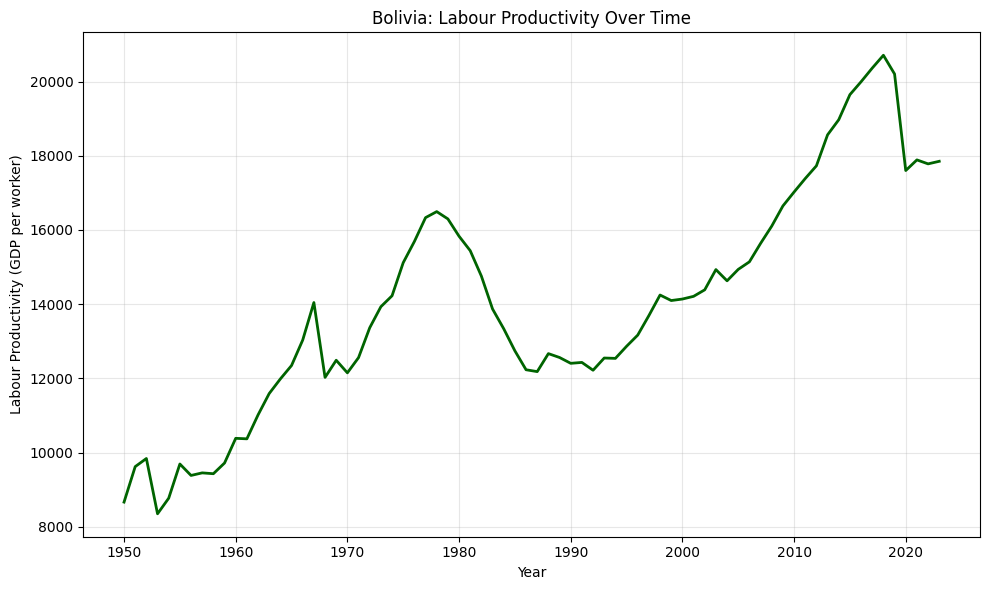


Figure saved to data/figures/


In [ ]:
# Labour productivity = GDP / workforce (not population!)
bolivia['labour_productivity'] = bolivia['rgdpna'] / bolivia['emp']
bolivia['ln_labour_prod'] = np.log(bolivia['labour_productivity'])

# Summary 
print("Labour Productivity Summary:")
print(bolivia['labour_productivity'].describe())

# Fig 6: Labour productivity over time
fig6, ax6 = plt.subplots(figsize=(10, 6))
ax6.plot(bolivia['year'], bolivia['labour_productivity'], linewidth=2, color='darkgreen')
ax6.set_xlabel('Year')
ax6.set_ylabel('Labour Productivity (GDP per worker)')
ax6.set_title('Bolivia: Labour Productivity Over Time')
ax6.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/figures/fig6_labour_productivity.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved to data/figures/")

--- 
### Extra plots

### TFP vs labour productivity over time

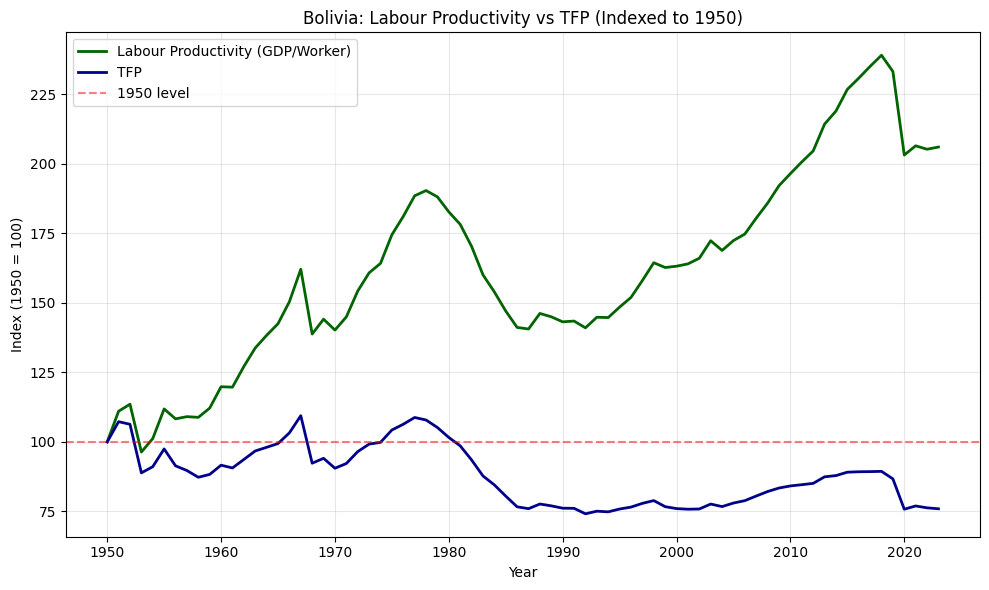


Growth from 1950 to 2023:
Labour Productivity: 106.0%
TFP: -24.0%

Figure saved to data/figures/


In [ ]:
# Compare TFP vs Labour Productivity growth rates
fig7, ax7 = plt.subplots(figsize=(10, 6))

# Normalize both to 1950 = 100 for comparison
base_tfp = bolivia['tfp'].iloc[0]
base_lp = bolivia['labour_productivity'].iloc[0]

normalized_tfp = 100 * bolivia['tfp'] / base_tfp
normalized_lp = 100 * bolivia['labour_productivity'] / base_lp

ax7.plot(bolivia['year'], normalized_lp, linewidth=2, color='darkgreen', label='Labour Productivity (GDP/Worker)')
ax7.plot(bolivia['year'], normalized_tfp, linewidth=2, color='darkblue', label='TFP')
ax7.axhline(y=100, color='red', linestyle='--', alpha=0.5, label='1950 level')
ax7.set_xlabel('Year')
ax7.set_ylabel('Index (1950 = 100)')
ax7.set_title('Bolivia: Labour Productivity vs TFP (Indexed to 1950)')
ax7.legend()
ax7.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/figures/fig7_labour_prod_vs_tfp.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nGrowth from 1950 to 2023:")
print(f"Labour Productivity: {((bolivia['labour_productivity'].iloc[-1] / bolivia['labour_productivity'].iloc[0]) - 1) * 100:.1f}%")
print(f"TFP: {((bolivia['tfp'].iloc[-1] / bolivia['tfp'].iloc[0]) - 1) * 100:.1f}%")

print("\nFigure saved to data/figures/")

---
### Capittal per worker

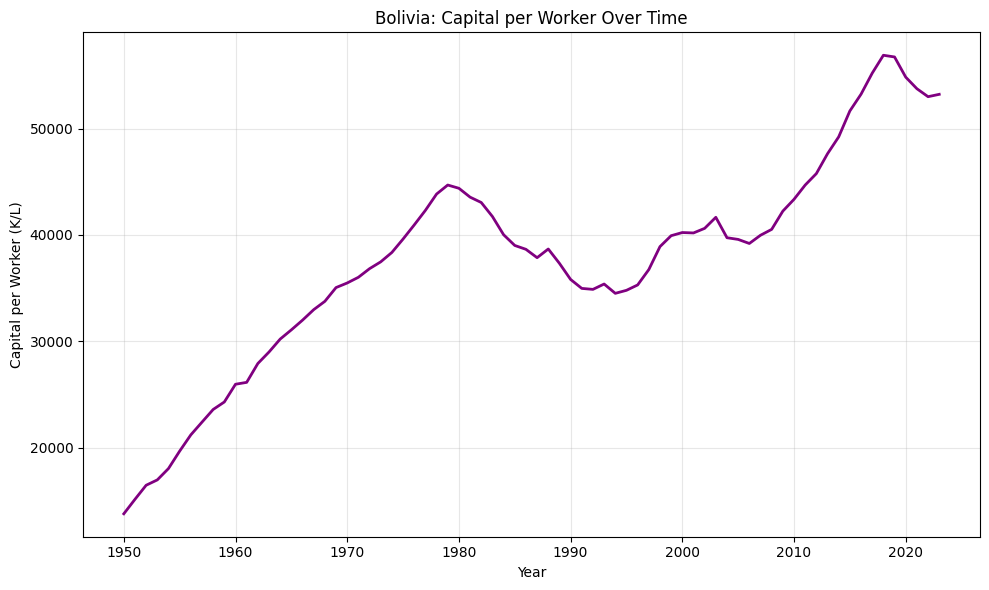

In [17]:
# Capital per Worker
bolivia['capital_per_worker'] = bolivia['rnna'] / bolivia['emp']

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(bolivia['year'], bolivia['capital_per_worker'], linewidth=2, color='purple')
ax.set_xlabel('Year')
ax.set_ylabel('Capital per Worker (K/L)')
ax.set_title('Bolivia: Capital per Worker Over Time')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/figures/fig_capital_per_worker.png', dpi=300, bbox_inches='tight')
plt.show()

---
### Overlay plot capital per worker,tfp, labour productivity

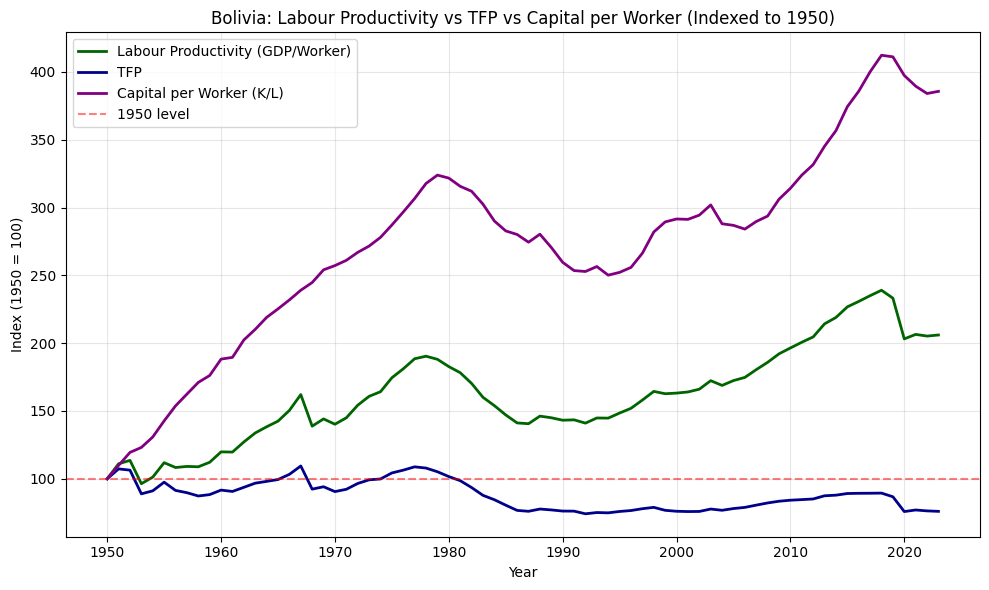

In [18]:
# Normalize all three to 1950 = 100
base_tfp = bolivia['tfp'].iloc[0]
base_lp = bolivia['labour_productivity'].iloc[0]
base_kl = bolivia['capital_per_worker'].iloc[0]

normalized_tfp = 100 * bolivia['tfp'] / base_tfp
normalized_lp = 100 * bolivia['labour_productivity'] / base_lp
normalized_kl = 100 * bolivia['capital_per_worker'] / base_kl

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(bolivia['year'], normalized_lp, linewidth=2, color='darkgreen', label='Labour Productivity (GDP/Worker)')
ax.plot(bolivia['year'], normalized_tfp, linewidth=2, color='darkblue', label='TFP')
ax.plot(bolivia['year'], normalized_kl, linewidth=2, color='purple', label='Capital per Worker (K/L)')
ax.axhline(y=100, color='red', linestyle='--', alpha=0.5, label='1950 level')
ax.set_xlabel('Year')
ax.set_ylabel('Index (1950 = 100)')
ax.set_title('Bolivia: Labour Productivity vs TFP vs Capital per Worker (Indexed to 1950)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/figures/fig8_lp_tfp_kl_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

---
### Bolivia ER over time

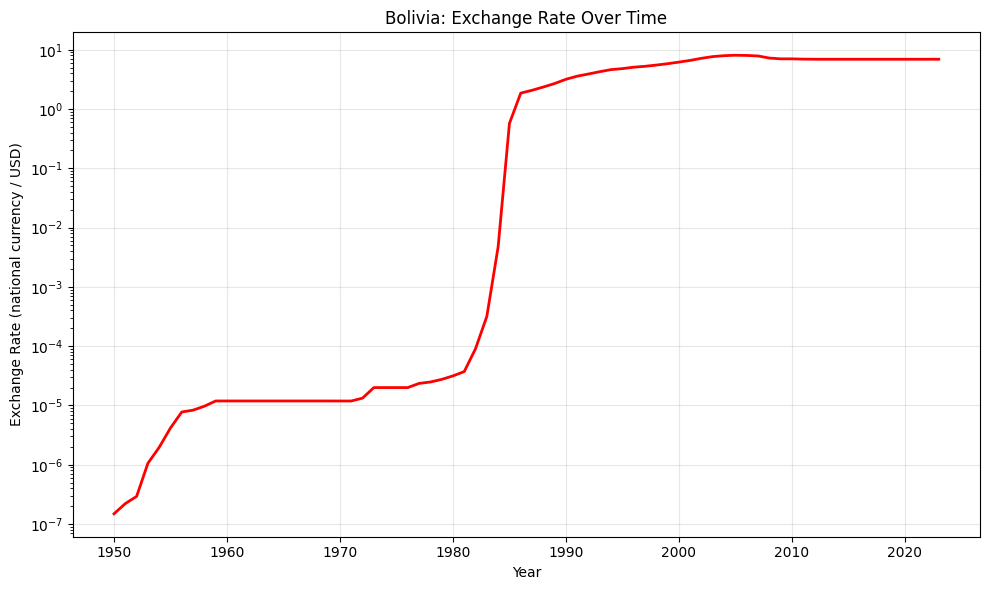

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(bolivia['year'], bolivia['xr'], linewidth=2, color='red')
ax.set_xlabel('Year')
ax.set_ylabel('Exchange Rate (national currency / USD)')
ax.set_title('Bolivia: Exchange Rate Over Time')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/figures/fig_exchange_rate.png', dpi=300, bbox_inches='tight')
plt.show()